# Infer

This notebook is notebook-driven on purpose: it shows the effective config at launch time, keeps `control`, `guided`, and `feedback` in separate passes, prints progress as runs happen, and persists all infer artifacts immediately.

In [2]:
import os
from datetime import UTC, datetime
from pathlib import Path

import pandas as pd
from IPython.display import JSON, SVG, display

from src.lib.analyze_pipeline import (
    collect_infer_snapshot_metrics,
    discover_infer_artifacts,
    render_model_snapshot_svg,
)
from src.lib.infer_pipeline import (
    SUPPORTED_SCENARIOS,
    build_config_snapshot,
    find_repo_root,
    load_feedback_prompt_bundle,
    load_prompt_bundle,
    load_runtime_config,
    load_source_matrix,
    parse_optional_int,
    process_feedback_run,
    process_run,
    rebuild_index,
    select_scenario_rows,
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

repo_root = find_repo_root(Path.cwd())
runtime_config = load_runtime_config(repo_root)
source_matrix = load_source_matrix(repo_root)
max_new_requests = parse_optional_int(os.getenv("INFER_MAX_NEW_REQUESTS"))
remaining_new_requests = max_new_requests

prompt_bundles = {
    scenario: load_prompt_bundle(repo_root, scenario)
    for scenario in SUPPORTED_SCENARIOS
}
guided_prompt_bundle = prompt_bundles["guided"]
feedback_prompt_bundle = load_feedback_prompt_bundle(repo_root)
scenario_rows = {
    scenario: select_scenario_rows(source_matrix, scenario)
    for scenario in SUPPORTED_SCENARIOS
}

all_summaries = []
latest_index_df = rebuild_index(repo_root)


def run_scenario_pass(scenario: str) -> pd.DataFrame:
    global remaining_new_requests, latest_index_df

    rows = scenario_rows[scenario]
    total_steps = len(rows) * runtime_config.runs
    scenario_summaries = []
    step = 0

    print(f"Started {scenario} at {datetime.now(UTC).isoformat()}")
    print(f"Rows: {len(rows)} | Runs per row: {runtime_config.runs} | Total steps: {total_steps}")
    print(f"Remaining new-request budget before pass: {remaining_new_requests}")

    for row in rows:
        for run_number in range(1, runtime_config.runs + 1):
            step += 1
            should_execute = remaining_new_requests is None or remaining_new_requests > 0
            if scenario == "feedback":
                summary, _record = process_feedback_run(
                    repo_root=repo_root,
                    row=row,
                    run_number=run_number,
                    runtime_config=runtime_config,
                    guided_prompt_bundle=guided_prompt_bundle,
                    feedback_prompt_bundle=feedback_prompt_bundle,
                    should_execute=should_execute,
                )
            else:
                summary, _record = process_run(
                    repo_root=repo_root,
                    row=row,
                    run_number=run_number,
                    runtime_config=runtime_config,
                    prompt_bundle=prompt_bundles[scenario],
                    should_execute=should_execute,
                )
            scenario_summaries.append(summary)
            all_summaries.append(summary)

            print(
                f"[{scenario} {step}/{total_steps}] {summary['status'].upper()} | "
                f"{summary['document']} | {summary['model']} | run {summary['run']}"
            )
            if scenario == "feedback":
                print(f"  step0: {summary['step0_cs_path']}")
                print(f"  notes: {summary['feedback_md_path']}")
            print(f"  final: {summary['final_cs_path']}")
            print(f"  meta:  {summary['metadata_path']}")
            if "error" in summary:
                print(f"  error: {summary['error']}")

            if summary["status"] == "executed" and remaining_new_requests is not None:
                remaining_new_requests -= 1
                print(f"  remaining new-request budget: {remaining_new_requests}")

    latest_index_df = rebuild_index(repo_root)
    scenario_df = pd.DataFrame(scenario_summaries)

    if not scenario_df.empty:
        display(scenario_df)
        display(scenario_df.groupby("status").size().to_frame("count").reset_index())
    else:
        print(f"No rows were produced for scenario {scenario}.")

    return scenario_df

In [3]:
config_snapshot = build_config_snapshot(
    repo_root=repo_root,
    runtime_config=runtime_config,
    source_matrix=source_matrix,
    max_new_requests=max_new_requests,
)

display(JSON(config_snapshot, expanded=True))
display(
    pd.DataFrame(
        [
            {
                "scenario": scenario,
                "rows": len(rows),
                "runs": runtime_config.runs,
                "planned_steps": len(rows) * runtime_config.runs,
            }
            for scenario, rows in scenario_rows.items()
        ]
    )
)

if latest_index_df.empty:
    print("No completed infer artifacts exist yet.")
else:
    display(latest_index_df[["scenario", "model", "document", "run", "final_cs_path"]])

<IPython.core.display.JSON object>

,scenario,rows,runs,planned_steps
0,control,18,1,18
1,guided,18,1,18
2,feedback,18,1,18


,scenario,model,document,run,final_cs_path
0,control,google/gemini-2.5-flash-lite,framework-laptop-13-specs.md,1,artifacts/infer/framework-laptop-13-specs/control/google-gemini-2-5-flash-lite/run1/final.cs
1,control,meta-llama/llama-3.2-3b-instruct,framework-laptop-13-specs.md,1,artifacts/infer/framework-laptop-13-specs/control/meta-llama-llama-3-2-3b-instruct/run1/final.cs
2,control,mistralai/ministral-3b-2512,framework-laptop-13-specs.md,1,artifacts/infer/framework-laptop-13-specs/control/mistralai-ministral-3b-2512/run1/final.cs
3,guided,google/gemini-2.5-flash-lite,framework-laptop-13-specs.md,1,artifacts/infer/framework-laptop-13-specs/guided/google-gemini-2-5-flash-lite/run1/final.cs
4,guided,meta-llama/llama-3.2-3b-instruct,framework-laptop-13-specs.md,1,artifacts/infer/framework-laptop-13-specs/guided/meta-llama-llama-3-2-3b-instruct/run1/final.cs
5,guided,mistralai/ministral-3b-2512,framework-laptop-13-specs.md,1,artifacts/infer/framework-laptop-13-specs/guided/mistralai-ministral-3b-2512/run1/final.cs
6,control,google/gemini-2.5-flash-lite,github-create-issue-api.md,1,artifacts/infer/github-create-issue-api/control/google-gemini-2-5-flash-lite/run1/final.cs
7,control,meta-llama/llama-3.2-3b-instruct,github-create-issue-api.md,1,artifacts/infer/github-create-issue-api/control/meta-llama-llama-3-2-3b-instruct/run1/final.cs
8,control,mistralai/ministral-3b-2512,github-create-issue-api.md,1,artifacts/infer/github-create-issue-api/control/mistralai-ministral-3b-2512/run1/final.cs
9,guided,google/gemini-2.5-flash-lite,github-create-issue-api.md,1,artifacts/infer/github-create-issue-api/guided/google-gemini-2-5-flash-lite/run1/final.cs


In [4]:
control_summary = run_scenario_pass("control")

Started control at 2026-04-28T21:37:18.298879+00:00
Rows: 18 | Runs per row: 1 | Total steps: 18
Remaining new-request budget before pass: None
[control 1/18] CACHED | framework-laptop-13-specs.md | google/gemini-2.5-flash-lite | run 1
  final: artifacts/infer/framework-laptop-13-specs/control/google-gemini-2-5-flash-lite/run1/final.cs
  meta:  artifacts/infer/framework-laptop-13-specs/control/google-gemini-2-5-flash-lite/run1/record.json
[control 2/18] CACHED | github-create-issue-api.md | google/gemini-2.5-flash-lite | run 1
  final: artifacts/infer/github-create-issue-api/control/google-gemini-2-5-flash-lite/run1/final.cs
  meta:  artifacts/infer/github-create-issue-api/control/google-gemini-2-5-flash-lite/run1/record.json
[control 3/18] CACHED | ikea-billy-mainual.md | google/gemini-2.5-flash-lite | run 1
  final: artifacts/infer/ikea-billy-mainual/control/google-gemini-2-5-flash-lite/run1/final.cs
  meta:  artifacts/infer/ikea-billy-mainual/control/google-gemini-2-5-flash-lite/run

,source_matrix_line,scenario,model,document,run,status,run_dir,step0_cs_path,feedback_md_path,final_cs_path,metadata_path
0,1,control,google/gemini-2.5-flash-lite,framework-laptop-13-specs.md,1,cached,artifacts/infer/framework-laptop-13-specs/control/google-gemini-2-5-flash-lite/run1,artifacts/infer/framework-laptop-13-specs/control/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/framework-laptop-13-specs/control/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/framework-laptop-13-specs/control/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/framework-laptop-13-specs/control/google-gemini-2-5-flash-lite/run1/record.json
1,2,control,google/gemini-2.5-flash-lite,github-create-issue-api.md,1,cached,artifacts/infer/github-create-issue-api/control/google-gemini-2-5-flash-lite/run1,artifacts/infer/github-create-issue-api/control/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/github-create-issue-api/control/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/github-create-issue-api/control/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/github-create-issue-api/control/google-gemini-2-5-flash-lite/run1/record.json
2,3,control,google/gemini-2.5-flash-lite,ikea-billy-mainual.md,1,cached,artifacts/infer/ikea-billy-mainual/control/google-gemini-2-5-flash-lite/run1,artifacts/infer/ikea-billy-mainual/control/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/ikea-billy-mainual/control/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/ikea-billy-mainual/control/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/ikea-billy-mainual/control/google-gemini-2-5-flash-lite/run1/record.json
3,4,control,google/gemini-2.5-flash-lite,king-arthur-pancakes.md,1,cached,artifacts/infer/king-arthur-pancakes/control/google-gemini-2-5-flash-lite/run1,artifacts/infer/king-arthur-pancakes/control/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/king-arthur-pancakes/control/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/king-arthur-pancakes/control/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/king-arthur-pancakes/control/google-gemini-2-5-flash-lite/run1/record.json
4,5,control,google/gemini-2.5-flash-lite,standard-fragment.md,1,cached,artifacts/infer/standard-fragment/control/google-gemini-2-5-flash-lite/run1,artifacts/infer/standard-fragment/control/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/standard-fragment/control/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/standard-fragment/control/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/standard-fragment/control/google-gemini-2-5-flash-lite/run1/record.json
5,6,control,google/gemini-2.5-flash-lite,stripe-payment-intent.md,1,cached,artifacts/infer/stripe-payment-intent/control/google-gemini-2-5-flash-lite/run1,artifacts/infer/stripe-payment-intent/control/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/stripe-payment-intent/control/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/stripe-payment-intent/control/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/stripe-payment-intent/control/google-gemini-2-5-flash-lite/run1/record.json
6,7,control,meta-llama/llama-3.2-3b-instruct,framework-laptop-13-specs.md,1,cached,artifacts/infer/framework-laptop-13-specs/control/meta-llama-llama-3-2-3b-instruct/run1,artifacts/infer/framework-laptop-13-specs/control/meta-llama-llama-3-2-3b-instruct/run1/step-0.cs,artifacts/infer/framework-laptop-13-specs/control/meta-llama-llama-3-2-3b-instruct/run1/feedback.md,artifacts/infer/framework-laptop-13-specs/control/meta-llama-llama-3-2-3b-instruct/run1/final.cs,artifacts/infer/framework-laptop-13-specs/control/meta-llama-llama-3-2-3b-instruct/run1/record.json
7,8,control,meta-llama/llama-3.2-3b-instruct,github-create-issue-api.md,1,cached,artifacts/infer/github-create-issue-api/control/meta-llama-llama-3-2-3b-instruct/run1,artifacts/infer/github-create-issue-api/control/m

,status,count
0,cached,18


In [5]:
guided_summary = run_scenario_pass("guided")

Started guided at 2026-04-28T21:37:18.337448+00:00
Rows: 18 | Runs per row: 1 | Total steps: 18
Remaining new-request budget before pass: None
[guided 1/18] CACHED | framework-laptop-13-specs.md | google/gemini-2.5-flash-lite | run 1
  final: artifacts/infer/framework-laptop-13-specs/guided/google-gemini-2-5-flash-lite/run1/final.cs
  meta:  artifacts/infer/framework-laptop-13-specs/guided/google-gemini-2-5-flash-lite/run1/record.json
[guided 2/18] CACHED | github-create-issue-api.md | google/gemini-2.5-flash-lite | run 1
  final: artifacts/infer/github-create-issue-api/guided/google-gemini-2-5-flash-lite/run1/final.cs
  meta:  artifacts/infer/github-create-issue-api/guided/google-gemini-2-5-flash-lite/run1/record.json
[guided 3/18] CACHED | ikea-billy-mainual.md | google/gemini-2.5-flash-lite | run 1
  final: artifacts/infer/ikea-billy-mainual/guided/google-gemini-2-5-flash-lite/run1/final.cs
  meta:  artifacts/infer/ikea-billy-mainual/guided/google-gemini-2-5-flash-lite/run1/record.j

,source_matrix_line,scenario,model,document,run,status,run_dir,step0_cs_path,feedback_md_path,final_cs_path,metadata_path
0,37,guided,google/gemini-2.5-flash-lite,framework-laptop-13-specs.md,1,cached,artifacts/infer/framework-laptop-13-specs/guided/google-gemini-2-5-flash-lite/run1,artifacts/infer/framework-laptop-13-specs/guided/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/framework-laptop-13-specs/guided/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/framework-laptop-13-specs/guided/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/framework-laptop-13-specs/guided/google-gemini-2-5-flash-lite/run1/record.json
1,38,guided,google/gemini-2.5-flash-lite,github-create-issue-api.md,1,cached,artifacts/infer/github-create-issue-api/guided/google-gemini-2-5-flash-lite/run1,artifacts/infer/github-create-issue-api/guided/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/github-create-issue-api/guided/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/github-create-issue-api/guided/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/github-create-issue-api/guided/google-gemini-2-5-flash-lite/run1/record.json
2,39,guided,google/gemini-2.5-flash-lite,ikea-billy-mainual.md,1,cached,artifacts/infer/ikea-billy-mainual/guided/google-gemini-2-5-flash-lite/run1,artifacts/infer/ikea-billy-mainual/guided/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/ikea-billy-mainual/guided/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/ikea-billy-mainual/guided/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/ikea-billy-mainual/guided/google-gemini-2-5-flash-lite/run1/record.json
3,40,guided,google/gemini-2.5-flash-lite,king-arthur-pancakes.md,1,cached,artifacts/infer/king-arthur-pancakes/guided/google-gemini-2-5-flash-lite/run1,artifacts/infer/king-arthur-pancakes/guided/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/king-arthur-pancakes/guided/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/king-arthur-pancakes/guided/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/king-arthur-pancakes/guided/google-gemini-2-5-flash-lite/run1/record.json
4,41,guided,google/gemini-2.5-flash-lite,standard-fragment.md,1,cached,artifacts/infer/standard-fragment/guided/google-gemini-2-5-flash-lite/run1,artifacts/infer/standard-fragment/guided/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/standard-fragment/guided/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/standard-fragment/guided/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/standard-fragment/guided/google-gemini-2-5-flash-lite/run1/record.json
5,42,guided,google/gemini-2.5-flash-lite,stripe-payment-intent.md,1,cached,artifacts/infer/stripe-payment-intent/guided/google-gemini-2-5-flash-lite/run1,artifacts/infer/stripe-payment-intent/guided/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/stripe-payment-intent/guided/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/stripe-payment-intent/guided/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/stripe-payment-intent/guided/google-gemini-2-5-flash-lite/run1/record.json
6,43,guided,meta-llama/llama-3.2-3b-instruct,framework-laptop-13-specs.md,1,cached,artifacts/infer/framework-laptop-13-specs/guided/meta-llama-llama-3-2-3b-instruct/run1,artifacts/infer/framework-laptop-13-specs/guided/meta-llama-llama-3-2-3b-instruct/run1/step-0.cs,artifacts/infer/framework-laptop-13-specs/guided/meta-llama-llama-3-2-3b-instruct/run1/feedback.md,artifacts/infer/framework-laptop-13-specs/guided/meta-llama-llama-3-2-3b-instruct/run1/final.cs,artifacts/infer/framework-laptop-13-specs/guided/meta-llama-llama-3-2-3b-instruct/run1/record.json
7,44,guided,meta-llama/llama-3.2-3b-instruct,github-create-issue-api.md,1,cached,artifacts/infer/github-create-issue-api/guided/meta-llama-llama-3-2-3b-instruct/run1,artifacts/infer/github-create-issue-api/guided/meta-llama-llama-3-2-3b-instruct/run1/

,status,count
0,cached,18


In [6]:
feedback_summary = run_scenario_pass("feedback")

Started feedback at 2026-04-28T21:37:18.380420+00:00
Rows: 18 | Runs per row: 1 | Total steps: 18
Remaining new-request budget before pass: None
[feedback 1/18] EXECUTED | framework-laptop-13-specs.md | google/gemini-2.5-flash-lite | run 1
  step0: artifacts/infer/framework-laptop-13-specs/feedback/google-gemini-2-5-flash-lite/run1/step-0.cs
  notes: artifacts/infer/framework-laptop-13-specs/feedback/google-gemini-2-5-flash-lite/run1/feedback.md
  final: artifacts/infer/framework-laptop-13-specs/feedback/google-gemini-2-5-flash-lite/run1/final.cs
  meta:  artifacts/infer/framework-laptop-13-specs/feedback/google-gemini-2-5-flash-lite/run1/record.json
[feedback 2/18] EXECUTED | github-create-issue-api.md | google/gemini-2.5-flash-lite | run 1
  step0: artifacts/infer/github-create-issue-api/feedback/google-gemini-2-5-flash-lite/run1/step-0.cs
  notes: artifacts/infer/github-create-issue-api/feedback/google-gemini-2-5-flash-lite/run1/feedback.md
  final: artifacts/infer/github-create-iss

,source_matrix_line,scenario,model,document,run,status,run_dir,step0_cs_path,feedback_md_path,final_cs_path,metadata_path
0,19,feedback,google/gemini-2.5-flash-lite,framework-laptop-13-specs.md,1,executed,artifacts/infer/framework-laptop-13-specs/feedback/google-gemini-2-5-flash-lite/run1,artifacts/infer/framework-laptop-13-specs/feedback/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/framework-laptop-13-specs/feedback/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/framework-laptop-13-specs/feedback/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/framework-laptop-13-specs/feedback/google-gemini-2-5-flash-lite/run1/record.json
1,20,feedback,google/gemini-2.5-flash-lite,github-create-issue-api.md,1,executed,artifacts/infer/github-create-issue-api/feedback/google-gemini-2-5-flash-lite/run1,artifacts/infer/github-create-issue-api/feedback/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/github-create-issue-api/feedback/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/github-create-issue-api/feedback/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/github-create-issue-api/feedback/google-gemini-2-5-flash-lite/run1/record.json
2,21,feedback,google/gemini-2.5-flash-lite,ikea-billy-mainual.md,1,executed,artifacts/infer/ikea-billy-mainual/feedback/google-gemini-2-5-flash-lite/run1,artifacts/infer/ikea-billy-mainual/feedback/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/ikea-billy-mainual/feedback/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/ikea-billy-mainual/feedback/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/ikea-billy-mainual/feedback/google-gemini-2-5-flash-lite/run1/record.json
3,22,feedback,google/gemini-2.5-flash-lite,king-arthur-pancakes.md,1,executed,artifacts/infer/king-arthur-pancakes/feedback/google-gemini-2-5-flash-lite/run1,artifacts/infer/king-arthur-pancakes/feedback/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/king-arthur-pancakes/feedback/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/king-arthur-pancakes/feedback/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/king-arthur-pancakes/feedback/google-gemini-2-5-flash-lite/run1/record.json
4,23,feedback,google/gemini-2.5-flash-lite,standard-fragment.md,1,executed,artifacts/infer/standard-fragment/feedback/google-gemini-2-5-flash-lite/run1,artifacts/infer/standard-fragment/feedback/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/standard-fragment/feedback/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/standard-fragment/feedback/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/standard-fragment/feedback/google-gemini-2-5-flash-lite/run1/record.json
5,24,feedback,google/gemini-2.5-flash-lite,stripe-payment-intent.md,1,executed,artifacts/infer/stripe-payment-intent/feedback/google-gemini-2-5-flash-lite/run1,artifacts/infer/stripe-payment-intent/feedback/google-gemini-2-5-flash-lite/run1/step-0.cs,artifacts/infer/stripe-payment-intent/feedback/google-gemini-2-5-flash-lite/run1/feedback.md,artifacts/infer/stripe-payment-intent/feedback/google-gemini-2-5-flash-lite/run1/final.cs,artifacts/infer/stripe-payment-intent/feedback/google-gemini-2-5-flash-lite/run1/record.json
6,25,feedback,meta-llama/llama-3.2-3b-instruct,framework-laptop-13-specs.md,1,executed,artifacts/infer/framework-laptop-13-specs/feedback/meta-llama-llama-3-2-3b-instruct/run1,artifacts/infer/framework-laptop-13-specs/feedback/meta-llama-llama-3-2-3b-instruct/run1/step-0.cs,artifacts/infer/framework-laptop-13-specs/feedback/meta-llama-llama-3-2-3b-instruct/run1/feedback.md,artifacts/infer/framework-laptop-13-specs/feedback/meta-llama-llama-3-2-3b-instruct/run1/final.cs,artifacts/infer/framework-laptop-13-specs/feedback/meta-llama-llama-3-2-3b-instruct/run1/record.json
7,26,feedback,meta-llama/llama-3.2-3b-instruct,github-create-issue-api.md,1,executed,artifacts/infer/github-create-issue-api/feedback/meta-llama-llama-3-

,status,count
0,executed,18


,document_stem,scenario,model,run,defined_type_count,line_count,parse_error_count
0,framework-laptop-13-specs,control,google/gemini-2.5-flash-lite,1,14,118,0
1,framework-laptop-13-specs,feedback,google/gemini-2.5-flash-lite,1,13,110,0
2,framework-laptop-13-specs,guided,google/gemini-2.5-flash-lite,1,13,104,0
3,github-create-issue-api,control,google/gemini-2.5-flash-lite,1,8,359,0
4,github-create-issue-api,feedback,google/gemini-2.5-flash-lite,1,7,346,0
5,github-create-issue-api,guided,google/gemini-2.5-flash-lite,1,8,360,0
6,ikea-billy-mainual,control,google/gemini-2.5-flash-lite,1,7,137,0
7,ikea-billy-mainual,feedback,google/gemini-2.5-flash-lite,1,7,54,0
8,ikea-billy-mainual,guided,google/gemini-2.5-flash-lite,1,8,57,0
9,king-arthur-pancakes,control,google/gemini-2.5-flash-lite,1,6,49,0


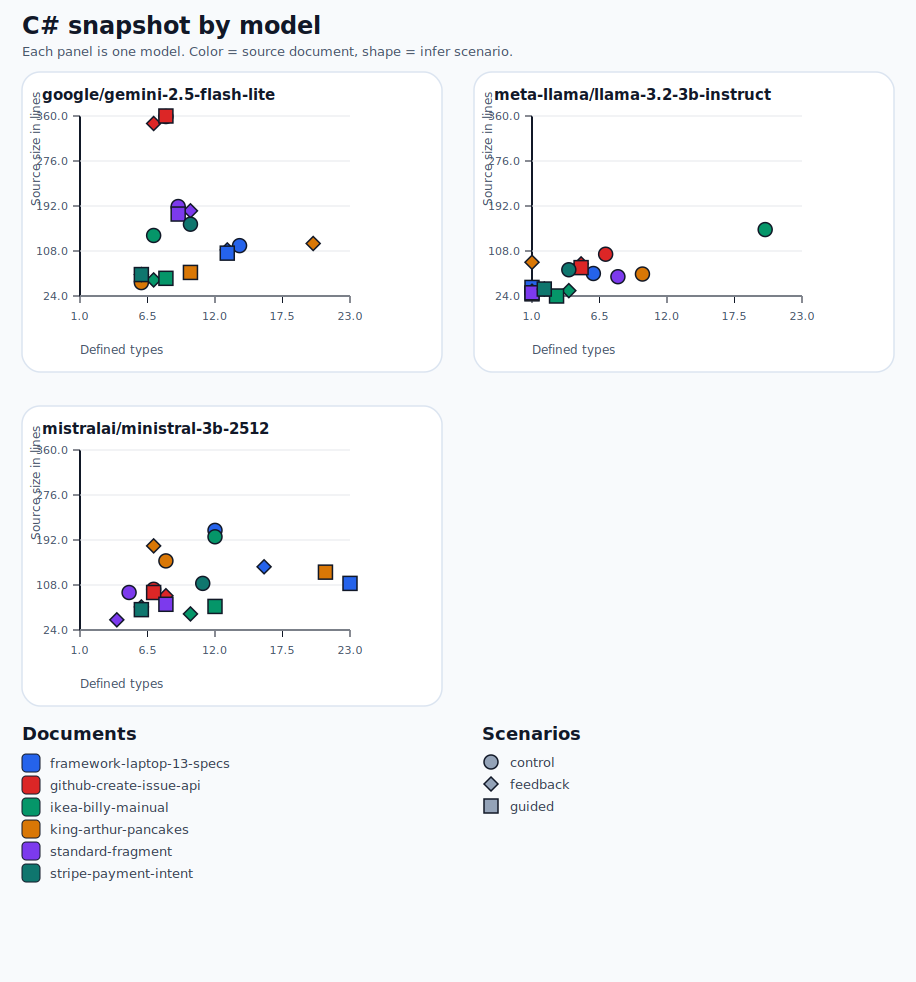

In [7]:
snapshot_artifact_df = discover_infer_artifacts(repo_root)
if snapshot_artifact_df.empty:
    print("No final.cs files available for the C# snapshot plot.")
else:
    snapshot_metrics_df = collect_infer_snapshot_metrics(repo_root, snapshot_artifact_df)
    display(snapshot_metrics_df[[
        "document_stem",
        "scenario",
        "model",
        "run",
        "defined_type_count",
        "line_count",
        "parse_error_count",
    ]])
    display(SVG(render_model_snapshot_svg(snapshot_metrics_df)))